<a href="https://colab.research.google.com/github/meerali4713-dotcom/AI-Major-minor-projects-/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#❤️ Cardiovascular Disease Prediction Using Machine Learning

##Introduction

Cardiovascular disease is one of the leading causes of death worldwide. Early detection of heart-related problems can help in timely treatment and improve patient outcomes. With the advancement of technology, machine learning techniques can be used to analyze medical data and predict the risk of disease.

In this project, a machine learning model is developed to predict whether a person is likely to have cardiovascular disease based on various health factors such as age, blood pressure, cholesterol levels, and lifestyle habits. By using different machine learning algorithms and comparing their performance, the most effective model is selected for prediction.

This project demonstrates how data analysis and machine learning can be applied in the healthcare domain to support better decision-making.

##Objetives



*   To analyze the cardiovascular dataset using data visualization techniques
*   To preprocess the data by handling duplicates and irrelevant features
*   To preprocess the data by handling duplicates and irrelevant features
*   To compare the performance of models using accuracy scores
*   To identify the best model for predicting heart disease
*   To build a system that can predict cardiovascular disease based on input data







##📥 1. Upload Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("cardio.csv", sep=';')

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Saving cardio.csv to cardio (1).csv
Dataset loaded successfully
Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df = df.drop("id", axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


##🧹2. Data Processing

In [12]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nDataset Info:")
df.info()

Missing Values:
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate Rows: 24

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 69976 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          69976 non-null  int64  
 1   gender       69976 non-null  int64  
 2   height       69976 non-null  int64  
 3   weight       69976 non-null  float64
 4   ap_hi        69976 non-null  int64  
 5   ap_lo        69976 non-null  int64  
 6   cholesterol  69976 non-null  int64  
 7   gluc         69976 non-null  int64  
 8   smoke        69976 non-null  int64  
 9   alco         69976 non-null  int64  
 10  active       69976 non-null  int64  
 11  cardio       69976 non-null  int64  
dtypes: float64(1), int64(11)
memory usa

### 🔹Convert Age from Days to Years

In [13]:
df["age"] = (df["age"] / 365).astype(int)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


### 🔹Statistical Summary

In [14]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,52.840874,1.349648,164.359152,74.208519,128.820453,96.636261,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771
std,6.767103,0.476862,8.211218,14.397211,154.037729,188.504581,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004
min,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


##📊✨3. Set Visualization Style

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)



### 🔹Heart Disease Distribution

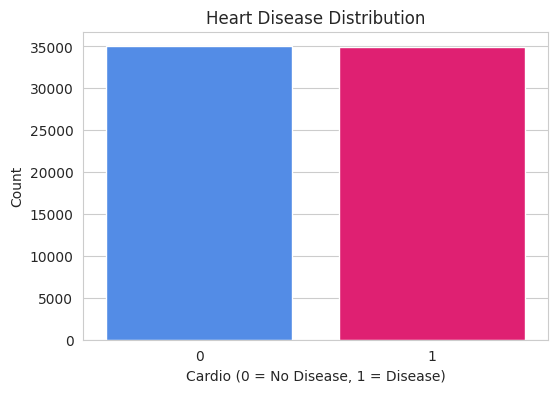

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="cardio", data=df, hue="cardio",
              palette=["#3A86FF", "#FF006E"], legend=False)
plt.title("Heart Disease Distribution")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

### 🔹Age Distribution

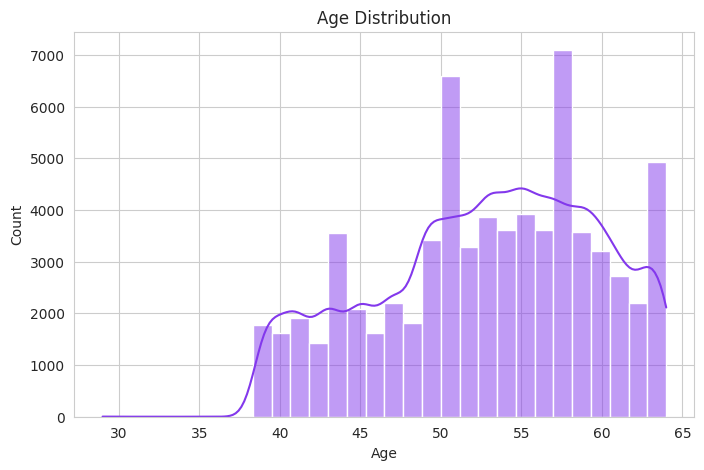

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True, color="#8338EC")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### 🔹Gender Distribution

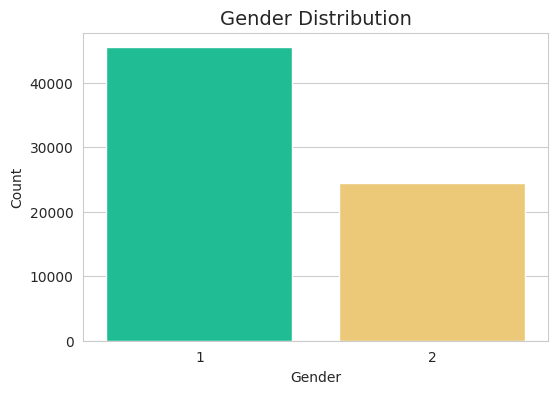

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df, hue="gender", palette=["#06D6A0", "#FFD166"], legend=False)
plt.title("Gender Distribution", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

###  🔹Cholesterol vs Heart Disease

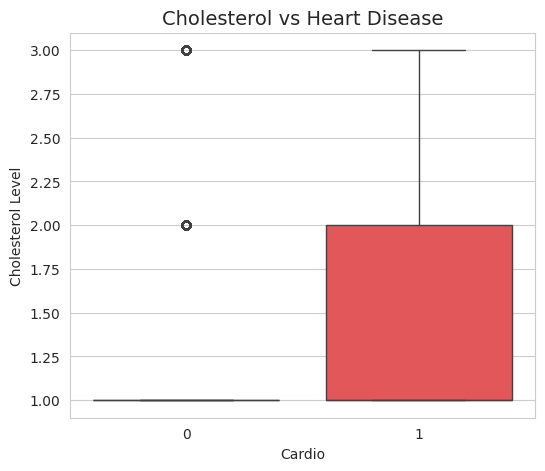

In [30]:
plt.figure(figsize=(6,5))
sns.boxplot(x="cardio", y="cholesterol", data=df, hue="cardio", palette=["#00B4D8", "#F94144"], legend=False)
plt.title("Cholesterol vs Heart Disease", fontsize=14)
plt.xlabel("Cardio")
plt.ylabel("Cholesterol Level")
plt.show()

### 🔹Glucose vs Heart Disease

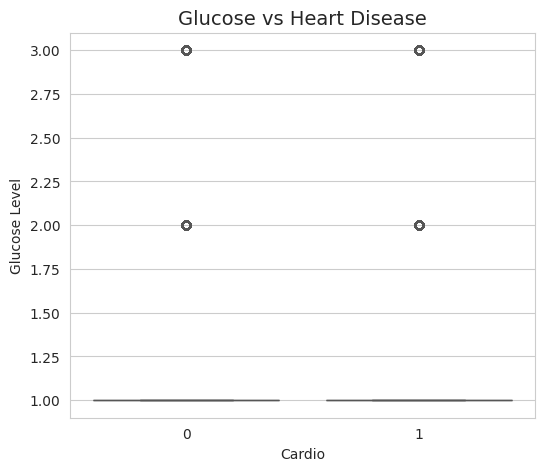

In [31]:
plt.figure(figsize=(6,5))
sns.boxplot(x="cardio", y="gluc", data=df, hue="cardio", palette=["#90BE6D", "#F3722C"], legend=False)
plt.title("Glucose vs Heart Disease", fontsize=14)
plt.xlabel("Cardio")
plt.ylabel("Glucose Level")
plt.show()

###  🔹Blood Pressure Analysis

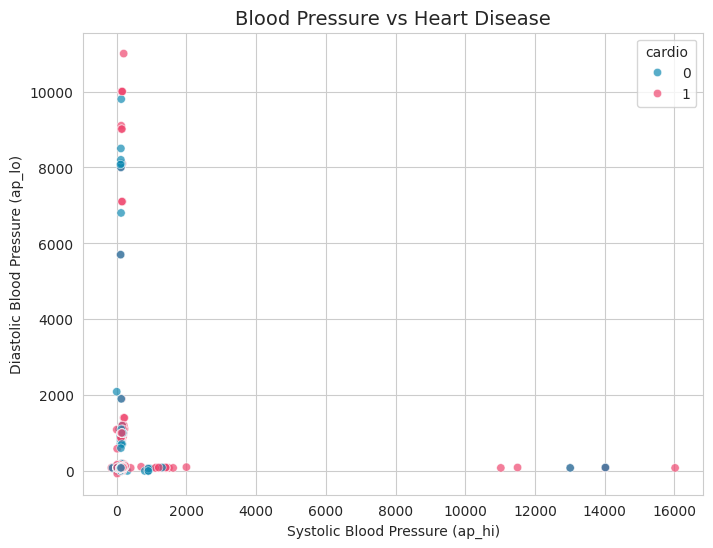

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="ap_hi",
    y="ap_lo",
    hue="cardio",
    data=df,
    palette=["#118AB2", "#EF476F"],
    alpha=0.7
)
plt.title("Blood Pressure vs Heart Disease", fontsize=14)
plt.xlabel("Systolic Blood Pressure (ap_hi)")
plt.ylabel("Diastolic Blood Pressure (ap_lo)")
plt.show()

##📈4. Correlation Matrix

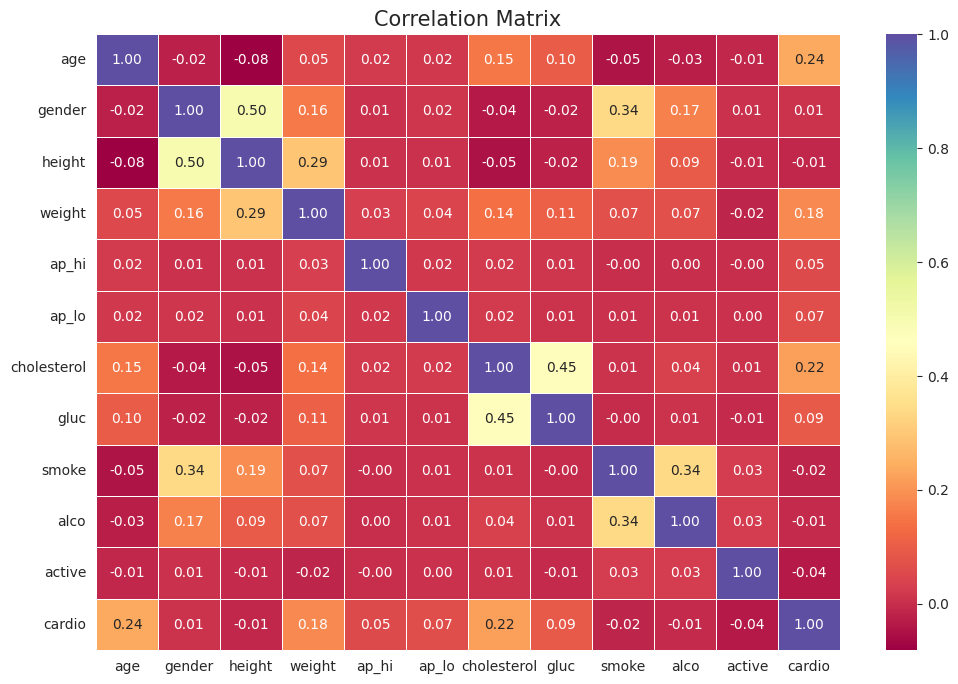

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Spectral", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=15)
plt.show()

##📈5. Pair Plot for Important Features

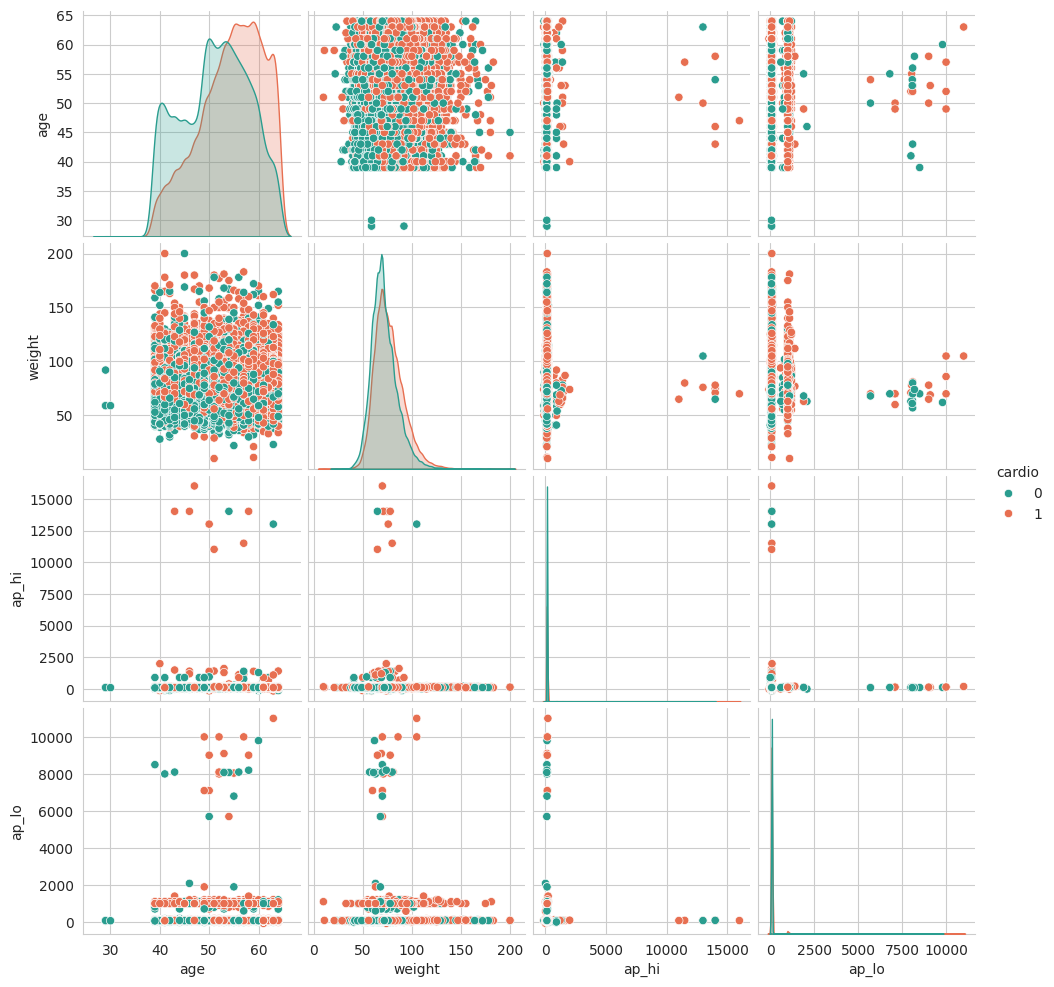

In [34]:
sns.pairplot(
    df[["age", "weight", "ap_hi", "ap_lo", "cardio"]],
    hue="cardio",
    palette={0: "#2A9D8F", 1: "#E76F51"}
)
plt.show()

## ⚙️6. Model Preparation

### 🔹 Feature and Target Separation

In [35]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (69976, 11)
Target shape: (69976,)


### 🔹 Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (55980, 11)
Testing data shape: (13996, 11)


### 🔹 Feature Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [43]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7164904258359531


## ⚙️7. Model Training

###  🔹K-Nearest Neighbor Model

In [44]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6469705630180052


###  🔹Support Vector Machine Model

In [45]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7265647327807945


###  🔹Decision Tree Model

In [46]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6311803372392112


###   🔹Random Forest Model

In [47]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7063446699056873


##📊⚖️8. Model Comparison

In [48]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_acc, knn_acc, svm_acc, dt_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.716490
1,KNN,0.646971
2,SVM,0.726565
3,Decision Tree,0.631180
4,Random Forest,0.706345


### 🔹Accuracy Comparison Chart

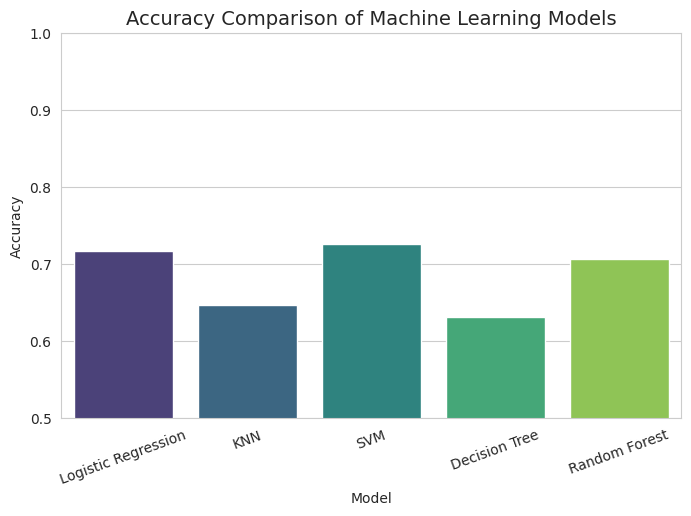

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results, hue="Model", palette="viridis", legend=False)
plt.title("Accuracy Comparison of Machine Learning Models", fontsize=14)
plt.xticks(rotation=20)
plt.ylim(0.5, 1.0)
plt.show()

##🏆9. Bset Model (RF)

In [50]:
best_model_name = results.loc[results["Accuracy"].idxmax(), "Model"]
best_accuracy = results["Accuracy"].max()

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: SVM
Best Accuracy: 0.7265647327807945


##🔍10. Evaluation

###🔹Classification Report


In [52]:
print("Classification Report for Random Forest:\n")
print(classification_report(y_test, rf_pred))

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.70      0.71      0.71      6901
           1       0.72      0.70      0.71      7095

    accuracy                           0.71     13996
   macro avg       0.71      0.71      0.71     13996
weighted avg       0.71      0.71      0.71     13996



###🔹ROC Curve

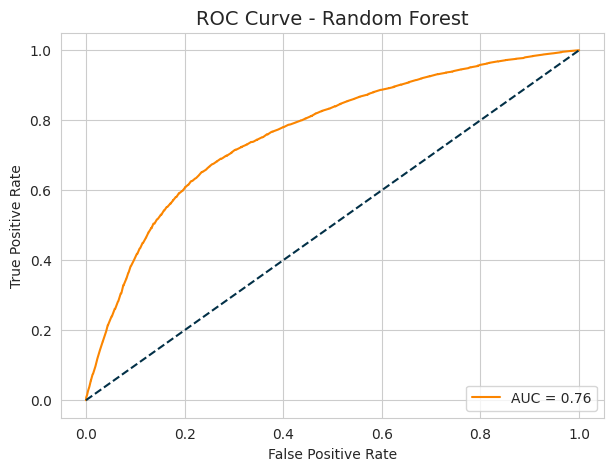

In [53]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#FB8500", label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], color="#023047", linestyle="--")
plt.title("ROC Curve - Random Forest", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

##⭐11. Feature Importance

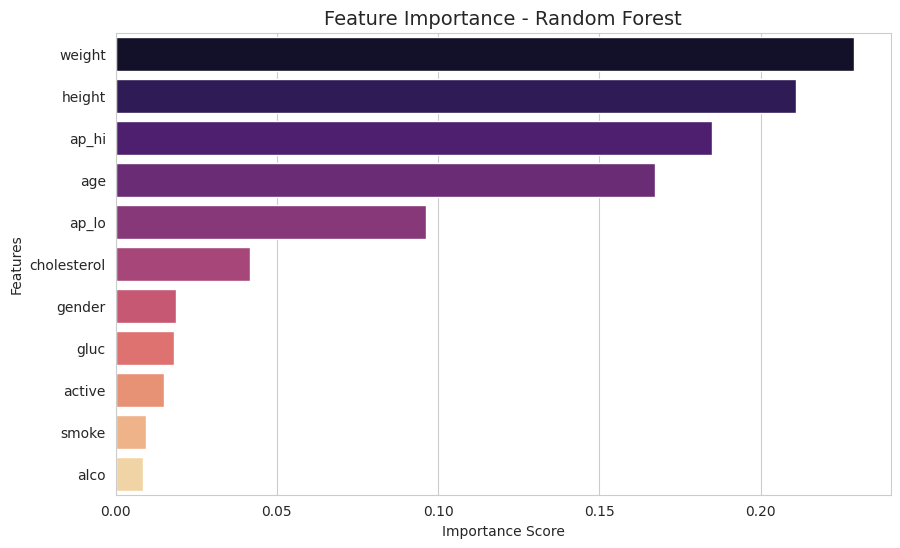

In [54]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, palette="magma", legend=False)
plt.title("Feature Importance - Random Forest", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

##🔮12. Prediction System

##🔹Final Prediction Function

In [55]:
def predict_heart_disease(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)
    prediction = rf.predict(input_data)

    if prediction[0] == 1:
        return "Heart Disease Detected"
    else:
        return "No Heart Disease"

##🔹Test the Prediction Function

In [57]:
import numpy as np
sample_data = [50, 2, 168, 62.0, 110, 80, 1, 1, 0, 0, 1]

result = predict_heart_disease(sample_data)
print(result)

Heart Disease Detected


##🧠Final Conclusion

In this project, a machine learning-based approach was used to predict cardiovascular disease using a patient dataset. The data was first preprocessed by removing unnecessary columns, handling duplicates, and converting age into years for better understanding. Various visualizations were created to analyze the relationships between features such as age, cholesterol, blood pressure, and heart disease.

Multiple machine learning models, including Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, and Random Forest, were trained and evaluated. The performance of each model was compared using accuracy scores. Among all the models, Random Forest performed the best, as it provided higher accuracy and handled the data more effectively.

Further evaluation using confusion matrix, classification report, and ROC curve helped in understanding the model’s performance in detail. Feature importance analysis also showed which factors contribute most to heart disease prediction.

Finally, a prediction function was developed to classify whether a person is likely to have cardiovascular disease based on input values. This project demonstrates how machine learning can be used effectively in healthcare to assist in early detection and decision-making.